# Block 3: Sequence Level

##### Authors: Josep de Cid and Gonzalo Recio

#### Imports and downloads

In [1]:
import nltk
import numpy as np
import time
from pprint import pprint
import termtables as tt

# POS treebank
nltk.download('treebank')

# Corpora for training data
nltk.download('conll2000')

[nltk_data] Downloading package treebank to /home/gonzalo/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     /home/gonzalo/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!


True

# Statement 1
- Use Machine Learning to build a chunker by learning sequences following next constraints:
    - Design your own feature set to represent samples
    - Use CRF as main algorithm
    - Use Conll2000 corpora as training data

### Chunker
A basic technique for entity detection is **chunking**, which segments and labels multi-token sequences. One example of this is detecting NP, VP and PP. We will start building a Chuncker based on a CRF model for detecting entities such as NP, VP or PP. For doing this, we need to predict the 2nd tag from the IOB Format.

In [2]:
from sklearn_crfsuite import CRF
from nltk.corpus import treebank, conll2000
from nltk.chunk import tree2conlltags, conlltags2tree

print('Conll2000 dataset: Tagged tokens for the first sentence in the IOB Chunking Format:\n')
pprint(tree2conlltags(conll2000.chunked_sents()[0][:4]))
print('...')

Conll2000 dataset: Tagged tokens for the first sentence in the IOB Chunking Format:

[('Confidence', 'NN', 'B-NP'),
 ('in', 'IN', 'B-PP'),
 ('the', 'DT', 'B-NP'),
 ('pound', 'NN', 'I-NP'),
 ('is', 'VBZ', 'B-VP'),
 ('widely', 'RB', 'I-VP'),
 ('expected', 'VBN', 'I-VP'),
 ('to', 'TO', 'I-VP'),
 ('take', 'VB', 'I-VP')]
...


Divide train and test sets

In [3]:
# 70/30 ratio for training/testing data
split_value = 70 * len(conll2000.tagged_sents()) // 100

# Transform to IOB Format
data = [tree2conlltags(sent) for sent in conll2000.chunked_sents()]

# Take 2nd tag
data_chunking = [[(x[0], x[-1]) for x in sent ] for sent in data]

train_data = data_chunking[:split_value]
test_data  = data_chunking[split_value:]

print(f'Training data samples: {len(train_data)}')
print(f'Test data samples: {len(test_data)}')

Training data samples: 7663
Test data samples: 3285


### Feature extraction
We are going to use **CRF Suite** package that allow us to train a CRF model using custom features (CRFTagger used in previous labs was quite limited for custom attributes).

We implemented a function for extracting the custom features form the sentences inspired in the example from CRF Suite library domumentation (https://sklearn-crfsuite.readthedocs.io/en/latest/tutorial.html) and extended to more features from the word context and the word itself.

In [4]:
def features_extraction(sentence, index):
    """ sentence: [(w1, tag1), (w2, tag2), ...], index: the index of the word in the sentence """
    sent = sentence.copy()
    i = index
    sentence = list(zip(*sentence))[0]
    if len(sentence[i]) == 0:
        return {'Empty': True}
    features =  {
        'word.lower()': sentence[index].lower(),
        'is_first': index == 0,
        'is_last': index == len(sentence) - 1,
        'is_capitalized': sentence[index][0].upper() == sentence[index][0],
        'is_all_caps': sentence[index].upper() == sentence[index],
        'is_all_lower': sentence[index].lower() == sentence[index],
        'prefix-1': sentence[index][0],
        'prefix-2': sentence[index][:2],
        'prefix-3': sentence[index][:3],
        'suffix-1': sentence[index][-1],
        'suffix-2': sentence[index][-2:],
        'suffix-3': sentence[index][-3:],
        'prev_word': '' if index == 0 else sentence[index - 1],
        'next_word': '' if index == len(sentence) - 1 else sentence[index + 1],
        'has_hyphen': '-' in sentence[index],
        'is_numeric': sentence[index].isdigit(),
        'is_upper': sentence[index].isupper(),
        'is_title': sentence[index].istitle(),
        'capitals_inside': sentence[index][1:].lower() != sentence[index][1:],
        'postag': sent[index][1],
        'postag[:2]': sent[index][1][:2], 
    }
    # Previous word features
    if i > 0:
        word1 = sent[i-1][0]
        postag1 = sent[i-1][1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
            '-1:postag': postag1,
            '-1:postag[:2]': postag1[:2],
        })
    else:
        # If there is no previous word, mark as beginning of sentence
        features['BOS'] = True

    # Next word features
    if i < len(sentence)-1:
        word1 = sent[i+1][0]
        postag1 = sent[i+1][1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
            '+1:postag': postag1,
            '+1:postag[:2]': postag1[:2],
        })
    else:
        # If there is no previous word, mark as end of sentence
        features['EOS'] = True
    return features


Convert raw train and test datasets to custom features dasasets

In [5]:
def transform_to_dataset(tagged_sentences):
    X, y = [], []
    for tagged in tagged_sentences:
        X.append([features_extraction(tagged, index) for index in range(len(tagged))])
        y.append([tag for _, tag in tagged])
    return X, y
 
X_train, y_train = transform_to_dataset(train_data)
X_test, y_test = transform_to_dataset(test_data)

### Model training (Chunking)

In [6]:
ts = time.time()
crf = CRF()
crf = crf.fit(X_train, y_train)
print(f'Training time: {time.time() - ts:.5f} seconds')

Training time: 70.19077 seconds


### Accuracy Evaluation (Chunking)

In [7]:
from sklearn_crfsuite import metrics

y_pred = crf.predict(X_test)
print(f'Accuracy: {metrics.flat_accuracy_score(y_test, y_pred)}')

Accuracy: 1.0


We can see that the model has an accuracy of 100% without any prediction mistake.

And these are the transitions that the model learned

In [8]:
from collections import Counter
def print_transitions(trans_features):
    for (label_from, label_to), weight in trans_features:
        print("%-6s -> %-7s %0.6f" % (label_from, label_to, weight))
print("Top likely transitions:")
print_transitions(Counter(crf.transition_features_).most_common(20))

Top likely transitions:
B-NP   -> I-NP    1.940801
B-VP   -> I-VP    1.780296
I-NP   -> I-NP    1.555442
I-VP   -> I-VP    1.471305
B-PP   -> I-PP    1.318053
I-PP   -> I-PP    0.735968
B-PP   -> B-NP    0.582182
B-NP   -> B-VP    0.564185
O      -> O       0.346636
I-NP   -> B-VP    0.328961
B-VP   -> B-NP    0.289098
O      -> B-VP    0.269709
B-VP   -> O       0.238386
O      -> B-NP    0.233296
I-VP   -> B-NP    0.174882
I-NP   -> B-PP    0.126665
I-PP   -> B-NP    0.087546
B-VP   -> B-PP    0.077638
B-NP   -> O       0.069320
B-NP   -> B-PP    0.068270


#### Example of the model performance with a selected sentence from test set

In [9]:
test_i = 10

example_sentence = [s[0] for s in test_data[test_i]]
real_tags_sentence = [s[1] for s in test_data[test_i]]
predicted_tags_sentence =  crf.predict([X_test[test_i]])[0]

prediction_errors = sum(map(lambda x: x[0] != x[1], zip(real_tags_sentence, predicted_tags_sentence)))

print(tt.to_string(
    data=np.array([example_sentence, real_tags_sentence, predicted_tags_sentence]).T,
    header=['Tokens', 'Real Tagging', 'Model Tagging'],
))

accuracy = metrics.flat_accuracy_score([real_tags_sentence], [predicted_tags_sentence])
print(f'Accuracy for the tested sentence: {accuracy:.5f}')
print(f'#errors: {prediction_errors}')

┌────────────┬──────────────┬───────────────┐
│ Tokens     │ Real Tagging │ Model Tagging │
╞════════════╪══════════════╪═══════════════╡
│ Much       │ B-NP         │ B-NP          │
├────────────┼──────────────┼───────────────┤
│ of         │ B-PP         │ B-PP          │
├────────────┼──────────────┼───────────────┤
│ HUD        │ B-NP         │ B-NP          │
├────────────┼──────────────┼───────────────┤
│ 's         │ B-NP         │ B-NP          │
├────────────┼──────────────┼───────────────┤
│ spending   │ I-NP         │ I-NP          │
├────────────┼──────────────┼───────────────┤
│ actually   │ O            │ O             │
├────────────┼──────────────┼───────────────┤
│ is         │ B-VP         │ B-VP          │
├────────────┼──────────────┼───────────────┤
│ disguised  │ B-NP         │ B-NP          │
├────────────┼──────────────┼───────────────┤
│ welfare    │ I-NP         │ I-NP          │
├────────────┼──────────────┼───────────────┤
│ for        │ B-PP         │ B-PP

###### Predicted parse tree

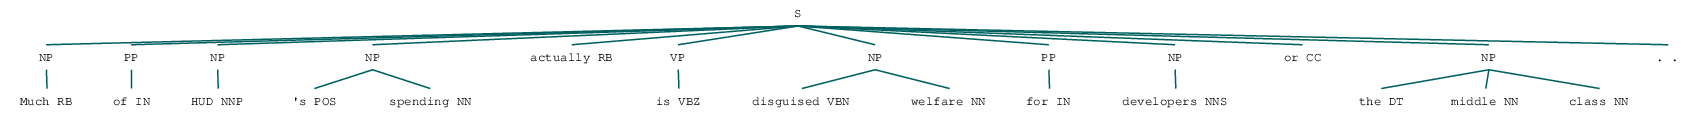

In [10]:
predicted_tree = zip(example_sentence,
                     [x[1] for x in data[split_value+test_i]],
                     predicted_tags_sentence)
conlltags2tree(predicted_tree)

###### Real parse tree

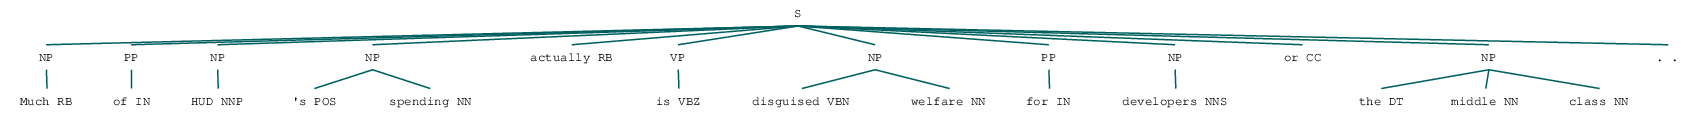

In [11]:
real_tree = zip(example_sentence,
                [x[1] for x in data[split_value+test_i]],
                real_tags_sentence)
conlltags2tree(real_tree)

Furthermore, we constructed the parsing trees for this sentence to see more easily that the trained CRF model predicts the same sentence chunking as real chunks.

----

# Statement 2
- Use Machine Learning to build a NER chunker learning sequences following next constraints:
    - Design your own feature set to represent samples
    - Use CRF as main algorithm
    - Use Conll2003 (English or German) or Conll2002 (Spanish or Dutch) corpora as training data


### Named Entity Recognition

In this case, the model structure is the same, we just need to change the data that we use to feed the model. From the given dataset (Conll2003), we are going to predict the 3rd tag which is the one related to NE classification. We can observe that the provided dataset has two tests sets (*test_a* and *test_b*).

#### Read Conll2003 dataset

In [12]:
import os

train = None
def read_data(file):
    path = os.path.join('.', 'conll2003', file) 
    with open(path, 'r') as f:
        sents = f.read().split('\n\n')[1:]
        sents = [s.split('\n') for s in sents]
        sents = [[(tag.split(' ')[0], tag.split(' ')[-1]) for tag in sent] for sent in sents]
        return sents

train_data = read_data('eng.train')
test_a = read_data('eng.testa')
test_b = read_data('eng.testb')

print(f'Training data samples: {len(train_data)}')
print(f'Test A data samples: {len(test_a)}')
print(f'Test B data samples: {len(test_b)}')

Training data samples: 14987
Test A data samples: 3466
Test B data samples: 3684


#### Convert raw datasets to custom feature dataset
We use the same custom features as in the Chunking exercise (Statement 1) because it is a complete feature extraction from the word itself and its contetex in the sentence.

In [13]:
X_train, y_train = transform_to_dataset(train_data)
X_test_a, y_test_a = transform_to_dataset(test_a)
X_test_b, y_test_b = transform_to_dataset(test_b)

### Model training (NER)

In [14]:
import time

ts = time.time()
crf_ne = CRF()
crf_ne = crf_ne.fit(X_train, y_train)
print(f'Training time: {time.time() - ts:.5f} seconds')

Training time: 92.93329 seconds


### Accuracy Evaluation (NER)

In [15]:
from sklearn_crfsuite import metrics

pred_a = crf_ne.predict(X_test_a) 
acc_a  = metrics.flat_accuracy_score(y_test_a, pred_a)
print(f'Accuracy for test_a: {acc_a:.5f}')

pred_b = crf_ne.predict(X_test_b)
acc_b  = metrics.flat_accuracy_score(y_test_b, pred_b)
print(f'accuracy for test_b: {acc_b:.5f}')

acc_mean = (acc_a + acc_b) / 2
print(f'Mean accuracy of NER for test: {acc_mean:.5f}')

Accuracy for test_a: 0.99996
accuracy for test_b: 0.99981
Mean accuracy of NER for test: 0.99988


#### Example of model performance with test data

In [16]:
test_i = 10

example_sentence = [s[0] for s in test_a[test_i]]
real_tags_sentence = [s[1] for s in test_a[test_i]]
predicted_tags_sentence =  crf_ne.predict([X_test_a[test_i]])[0]

prediction_errors = sum(map(lambda x: x[0] != x[1], zip(real_tags_sentence, predicted_tags_sentence)))

print(tt.to_string(
    data=np.array([example_sentence, real_tags_sentence, predicted_tags_sentence]).T,
    header=['Tokens', 'Real NE', 'Model NE'],
))

accuracy = metrics.flat_accuracy_score([real_tags_sentence], [predicted_tags_sentence])
print(f'Accuracy for the tested sentence: {accuracy:.5f}')
print(f'#errors: {prediction_errors}')

┌─────────┬─────────┬──────────┐
│ Tokens  │ Real NE │ Model NE │
╞═════════╪═════════╪══════════╡
│ He      │ O       │ O        │
├─────────┼─────────┼──────────┤
│ was     │ O       │ O        │
├─────────┼─────────┼──────────┤
│ well    │ O       │ O        │
├─────────┼─────────┼──────────┤
│ backed  │ O       │ O        │
├─────────┼─────────┼──────────┤
│ by      │ O       │ O        │
├─────────┼─────────┼──────────┤
│ England │ I-LOC   │ I-LOC    │
├─────────┼─────────┼──────────┤
│ hopeful │ O       │ O        │
├─────────┼─────────┼──────────┤
│ Mark    │ I-PER   │ I-PER    │
├─────────┼─────────┼──────────┤
│ Butcher │ I-PER   │ I-PER    │
├─────────┼─────────┼──────────┤
│ who     │ O       │ O        │
├─────────┼─────────┼──────────┤
│ made    │ O       │ O        │
├─────────┼─────────┼──────────┤
│ 70      │ O       │ O        │
├─────────┼─────────┼──────────┤
│ as      │ O       │ O        │
├─────────┼─────────┼──────────┤
│ Surrey  │ I-ORG   │ I-ORG    │
├─────────

For this sentence example, we can observe there aren't mistagging, having an accuracy of 1.

To go further, let's see which are the errors commited by the model when tagging Named Entities.

In [17]:
def evaluate_errors(test):
    false_positives = 0
    false_negatives = 0
    invalids = 0

    for sample in test:
        sample_sentence = [s[0] for s in sample]
        real_tags_sentence = [s[1] for s in sample]
        features = transform_to_dataset([sample])[0]
        predicted_tags_sentence = crf_ne.predict(features)[0]
        for el in zip(real_tags_sentence, predicted_tags_sentence):
            if el[0] != el[1]:
                if el[0] == 'O':
                    false_positives += 1
                elif el[1] == 'O':
                    false_negatives += 1
                else:
                    print(sample_sentence, el)
                    invalids += 1

    print(f'\nNon-NE predicted as NE: {false_positives}')
    print(f'NE predicted as non-NE: {false_negatives}')
    print(f'Invalid predicted NE: {invalids}')
    
print('\nErrors with test A\n', '-'*20)
evaluate_errors(test_a)

print()

print('\nErrors with test B\n', '-'*20)
evaluate_errors(test_b)


Errors with test A
 --------------------
['', ''] ('', 'I-PER')
['', ''] ('', 'I-PER')

Non-NE predicted as NE: 0
NE predicted as non-NE: 0
Invalid predicted NE: 2


Errors with test B
 --------------------
['5-2', 'Real', 'Madrid', 'Real', 'Madrid'] ('B-ORG', 'I-ORG')
['28-1', 'Real', 'Madrid', 'Barcelona'] ('B-ORG', 'I-ORG')
['25-1', 'Barcelona', 'Real', 'Madrid'] ('B-ORG', 'I-ORG')
['4-1', 'Barcelona', 'Barcelona'] ('B-ORG', 'I-ORG')
['Real', 'Madrid', 'Barcelona'] ('B-ORG', 'I-ORG')
['Buenos', 'Aires', 'Quequen', 'Rosario', 'Bahia', 'Blanca'] ('B-LOC', 'B-MISC')
['Buenos', 'Aires', 'Quequen', 'Rosario', 'Bahia', 'Blanca'] ('B-LOC', 'I-LOC')
['', ''] ('', 'I-PER')
['', ''] ('', 'I-PER')

Non-NE predicted as NE: 0
NE predicted as non-NE: 0
Invalid predicted NE: 9


---

# Conclusions

### Chunker
With the trained CRF model for Chunking sentences we obtained an accuracy of **100%**, showing the great performance of CRFs for parsing sentences. The model takes 15 seconds to train with 15000 samples.

### Named Entity Recognition
After training the classifier, which takes 30 seconds with 15000 samples, we get a very high accuracy in our test samples, **99.989%**, doing the mean of both test sets (*test_a* and *test_b*).

If we take a look in-depth on the few error types, we see that they aren't because of not detecting correctly that there is a named entity but because of slightly missclassifying the tag. Therefore, the only errors of the model are classifying properly NEs into their categories and not to distinguish between NE and non-NE.
Examples of the misclassification tags are the following (Real-Tag, Predicted-Tag): 
 - ('B-ORG', 'I-ORG'), ('B-LOC', 'B-MISC'), ('B-LOC', 'I-LOC')

-------


Hence, we can conclude that a CRF is an excellent model for this task in particular and other tasks consisting on word-level sentences tagging.